# Agentic Hybrid RAG with Dynamic Routing


# Problem Statement / Use Case Overview

A self-correcting agent that only knows how to search one way — plain vector similarity, say — is still limited by what that one method is good at. Some questions are really about *meaning* ("what is X?"), and a vector search handles those well. Other questions are really about *connections* ("what is X linked to, and what is that linked to?"), and a graph traversal handles those far better. Forcing every question through the same tool means one type of question always gets a worse-than-necessary search.


### How This Lab Solves It

This lab builds a version that gives the agent a choice. Before retrieving anything, a **router** step reads the question and decides which of two tools fits it best: a **graph traversal** through Neo4j, for questions about connections and components, or a **vector search** over the same Neo4j data, for questions about general meaning. If the chosen tool comes back with weak results, the agent doesn't just rewrite the question right away — it first tries **switching tools** on the very next attempt, since a bad result is sometimes a sign the wrong tool was picked, not that the question itself was badly worded. Only if that swapped tool also comes up short does the agent fall back to rewriting the question, the same way as before.

**This pipeline has five connected parts, wired together as a loop:**

1. **Router** — read the question and decide: graph traversal, or vector search?
2. **Retrieve** — run whichever tool was chosen.
3. **Grade** — ask the LLM whether the retrieved facts are actually useful.
4. **Fallback** — if not, and retries remain: swap to the other tool on the first failure, or rewrite the question on the second.
5. **Generate** — once the facts are judged useful (or retries run out), answer using only those facts.

This is useful for:
- **Mixed question types in one pipeline** — some questions need meaning-based search, others need relationship-based search, and the agent picks the right one automatically instead of a person having to choose.
- **Recovering from a wrong tool choice, not just a bad question** — swapping tools first means a good question isn't needlessly rewritten just because the router happened to pick the less suitable tool.
- **Multi-hop questions** — ones that depend on following a relationship from one concept to another — which a graph traversal is naturally suited to answer, and a plain vector search would tend to miss.


# Input Data

| Item | Detail |
|------|--------|
| **The PDF** | A document downloaded automatically from a link |
| **Your question** | A natural-language question — could be meaning-based or connection-based |
| **LLM API Key** | Used to route, grade, rewrite, and generate |
| **Neo4j Aura credentials** | A URI, username, and password for a running Neo4j Aura instance |
| **Embedding model** | Runs locally — no API key needed, downloaded automatically the first time it's used |


# Processing


### Part A — Ingestion

Before any question can be routed or answered, the PDF has to be turned into a graph that both tools can search:

```mermaid
flowchart LR
    PDF["PDF link"] --> DL["Download PDF"]
    DL --> EX["Extract text"]
    EX --> LLM["LLM extracts nodes<br/>+ relationships"]
    LLM --> N4J["Written into Neo4j"]
    N4J --> EMB["Every node embedded<br/>+ vector index built"]

    classDef ingestStyle fill:#eef7ee,stroke:#3a7d3a,stroke-width:1px,color:#111111
    class PDF,DL,EX,LLM,N4J,EMB ingestStyle
```

This is the same kind of graph-plus-vectors setup used for hybrid retrieval — nodes and relationships are extracted and written into Neo4j, then every node is embedded and a vector index is built on top. Both tools available to the agent search this exact same graph; they just search it differently.


### Part B — The Routing and Self-Correction Loop

```mermaid
flowchart LR
    Q["Question"] --> RT["Router: choose GRAPH or VECTOR"]
    RT --> R["Retrieve using the chosen tool"]
    R --> G{"Grade: are these<br/>facts useful?"}
    G -->|YES| Gen["Generate final answer"]
    G -->|"NO, retries left"| FB["Fallback: swap tool,<br/>or rewrite question"]
    FB --> R
    G -->|"NO, out of retries"| Gen

    classDef defaultStyle fill:#ffffff,stroke:#333333,stroke-width:1px,color:#111111
    classDef decisionStyle fill:#fff3cd,stroke:#d68f00,stroke-width:1px,color:#1a1a1a
    class Q,RT,R,FB,Gen defaultStyle
    class G decisionStyle
```

This is the shape of the whole pipeline. A router decision happens once, right at the start, before anything is retrieved. From there, the loop looks similar to a simpler self-correcting agent — retrieve, grade, and either move on or try again — except the fallback step now has two different ways to try again, not just one.


### Part C — How the Router Decides

```mermaid
flowchart LR
    Q2["Question"] --> Check{"What is this<br/>question really asking?"}
    Check -->|"connections, components,<br/>multi-hop relationships"| GraphTool["GRAPH tool<br/>(traverse Neo4j relationships)"]
    Check -->|"general meaning,<br/>definitions, broad topics"| VectorTool["VECTOR tool<br/>(similarity search over node names)"]

    classDef defaultStyle fill:#ffffff,stroke:#333333,stroke-width:1px,color:#111111
    class Q2,Check,GraphTool,VectorTool defaultStyle
```

The router doesn't run any search itself — it only asks the LLM to read the question and reply with one word, `GRAPH` or `VECTOR`, based on which kind of search seems more likely to help. That single word becomes `state["current_tool"]`, and every later step in that attempt uses whichever tool was chosen.


### Part D — How the Fallback Step Decides What to Try Next

```mermaid
flowchart LR
    Fail["Grade came back NO"] --> Check2{"Is this the<br/>first failure?"}
    Check2 -->|"Yes (retry_count is 0)"| Swap["Swap tool:<br/>GRAPH becomes VECTOR,<br/>or VECTOR becomes GRAPH"]
    Check2 -->|"No (retry_count is 1 or more)"| Rewrite["Rewrite the question"]
    Swap --> Inc["retry_count += 1"]
    Rewrite --> Inc

    classDef defaultStyle fill:#ffffff,stroke:#333333,stroke-width:1px,color:#111111
    classDef decisionStyle fill:#fff3cd,stroke:#d68f00,stroke-width:1px,color:#1a1a1a
    class Fail,Swap,Rewrite,Inc defaultStyle
    class Check2 decisionStyle
```

This is what makes the fallback step different from a simple retry: it doesn't always do the same thing. On the very first failure, it assumes the router might have picked the less suitable tool, so it swaps to the other one and searches again with the same question. Only if that swapped tool *also* fails does it fall back to rewriting the question itself, the same approach used in a simpler self-correcting setup.


### Part E — How the Pipeline Is Wired

```mermaid
flowchart LR
    StartNode(["START"]) --> router["router"]
    router --> retrieve["retrieve"]
    retrieve --> grade["grade"]
    grade -->|"generate"| generate["generate"]
    grade -->|"fallback"| fallback["fallback"]
    fallback --> retrieve
    generate --> EndNode(["END"])

    classDef defaultStyle fill:#ffffff,stroke:#333333,stroke-width:1px,color:#111111
    classDef terminalStyle fill:#e7f1ff,stroke:#1d6fa5,stroke-width:1px,color:#0b1f33
    class router,retrieve,grade,fallback,generate defaultStyle
    class StartNode,EndNode terminalStyle
```

This is the actual structure the notebook builds. `router` always runs first and only once — after that, the loop moves between `retrieve`, `grade`, and (if needed) `fallback`, exactly the way a simpler self-correcting agent's loop does, just with an extra decision baked into the fallback step itself.


### Walking Through Both Fallback Strategies

The example run in this lab gets a good grade on the very first try, using the graph tool the router picked. To see both fallback strategies in action, here's how the state would move if that first attempt had failed, and then the swapped tool had failed too:

```mermaid
flowchart TB
    subgraph A1["Attempt 1"]
        T1["tool: GRAPH (router's choice)"] --> R1["retrieve"] --> G1["grade: NO"]
    end

    G1 -->|"retry_count 0 to 1<br/>first failure: swap tool"| T2["tool: VECTOR"]

    subgraph A2["Attempt 2"]
        T2 --> R2["retrieve"] --> G2["grade: NO"]
    end

    G2 -->|"retry_count 1 to 2<br/>second failure: rewrite question"| Q3["question: rewritten wording"]

    subgraph A3["Attempt 3"]
        Q3 --> R3["retrieve (same tool: VECTOR)"] --> G3["grade: YES"]
    end

    G3 --> Gen["generate final answer"]

    classDef defaultStyle fill:#ffffff,stroke:#333333,stroke-width:1px,color:#111111
    class T1,R1,G1,T2,R2,G2,Q3,R3,G3,Gen defaultStyle

    style A1 fill:#eef3fb,stroke:#5b7fa6,stroke-width:1px,color:#1a1a1a
    style A2 fill:#eef3fb,stroke:#5b7fa6,stroke-width:1px,color:#1a1a1a
    style A3 fill:#eef3fb,stroke:#5b7fa6,stroke-width:1px,color:#1a1a1a
```

Notice that the question itself doesn't change between Attempt 1 and Attempt 2 — only the tool changes. It's only by Attempt 3, after the swapped tool also failed, that the question gets rewritten. This is the key difference from a simpler self-correcting loop: the very first fallback attempt costs nothing in terms of rephrasing, since it's testing whether a different search method solves the problem before assuming the question was the issue.


# Output

**Configuring the LLM and embeddings** confirms both are ready:

```
LLM and Embedding Models configured successfully!
```

**Connecting to Neo4j** confirms the database connection:

```
Connected to Neo4j successfully!
```

**Downloading and extracting the PDF** prints the character count pulled from it:

```
Downloading PDF from https://arxiv.org/pdf/1706.03762.pdf...
PDF downloaded to data/downloaded_paper.pdf!
Extracted 1500 characters of raw document text.
```

**Clearing and ingesting the graph** confirms the database is reset, then how much was written:

```
Cleared existing Neo4j database.
Ingested 35 nodes and 31 relationships into Neo4j.
```

**Building the vector index** confirms every node was embedded:

```
Neo4j Vector Index created and embeddings populated!
```


**Compiling the agent graph** confirms the nodes and edges wired together correctly:

```
Agentic Hybrid RAG Graph compiled successfully!
```

**Running the agent** on the question *"What models or mechanisms are sequence transduction models based on or connected to?"* prints the router's decision, the retrieval step, the grade, and the retry count:

```
ROUTER DECISION: Using GRAPH Tool.
Retrieving for: 'What models or mechanisms are sequence transduction models based on or connected to?' via GRAPH Tool
Grade: YES
Total Retries: 0
```

**The final answer** comes back in the same two-part format used throughout:

```
--- FINAL ANSWER ---
Sequence transduction models are based on recurrent neural networks and
convolutional neural networks, and they use encoder and decoder mechanisms.

--- EXPLAINABILITY ---
The answer is derived from the facts that sequence transduction models are
BASED_ON recurrent neural networks and convolutional neural networks, and
that they USE an encoder and a decoder. The fact that recurrent neural
networks are also BASED_ON sequence transduction models indicates a
bidirectional connection between the two.
```

The question — asking what sequence transduction models are "based on or connected to" — is exactly the kind of multi-hop, connection-based question the router is meant to send toward the graph tool, and that's exactly what it chose here, on the very first attempt, with no fallback needed.


# Tech Stack

| Component | Tool |
|---|---|
| **PDF Text Extraction** | `pypdf` — pulls raw text out of the PDF |
| **File Downloading** | `requests` — grabs the PDF from a link |
| **Entity/Relationship Extraction** | LLM (`openai/gpt-oss-20b:free`) — reads text and returns nodes + relationships as JSON |
| **Graph Storage** | `Neo4j Aura` (cloud-hosted Neo4j) — stores nodes, relationships, and their embeddings together |
| **Database Driver** | `neo4j` Python driver |
| **Query Language** | `Cypher`, including a native vector index for similarity search |
| **Embedding Model** | `sentence-transformers` / `all-MiniLM-L6-v2`, via `langchain-huggingface` — runs locally |
| **LLM (Routing, Grading, Rewriting, Answering)** | `openai/gpt-oss-20b:free`, via `langchain-openai`'s `ChatOpenAI` wrapper |
| **Agent Orchestration** | `langgraph` — wires router, retrieve, grade, fallback, and generate into a loopable graph |
| **Graph Visualization** | `yfiles_jupyter_graphs` — renders the raw Neo4j query result as an interactive widget |


# Underlying Concepts (Summarized)

**Dynamic Tool Routing** means the agent doesn't always use the same retrieval method — a routing step decides, per question, which tool is more likely to work. This is what turns a single-method agent into one with a small toolbox to choose from.

**Two-Stage Fallback** is a fallback strategy that tries the cheaper fix first. Swapping tools costs nothing extra in terms of rewriting the question, and only if that doesn't help does the agent fall back to rewriting the question itself, which is a bigger change to make.

**Graph Tool vs Vector Tool** — both search the same Neo4j data, but differently. The vector tool looks for node names closest in meaning to the question and returns them directly. The graph tool finds the closest node first, then follows its relationships outward, returning full connection paths rather than single names — which is what makes it better suited to questions about how things relate to each other.

**Multi-Hop Question** is a question whose answer depends on following more than one connection — not just "what is X," but "what is X connected to, and what does that lead to." These are the kinds of questions the graph tool is specifically chosen for.

> **Why this matters:** The question used in the sample run — "what are sequence transduction models based on or connected to" — is really a request to follow relationships outward from one concept, not to find text that merely sounds similar. Handing that kind of question to a plain vector search would likely miss the connected facts entirely. Routing it to the graph tool lets it be answered by following the exact relationships stored in the graph.


# Pre-requisites

- **Basic familiarity** with Python (functions, loops, `import` statements, dictionaries).
- **Familiarity with a Neo4j knowledge graph and its vector index** — nodes, relationships, Cypher, and vector-based similarity search.
- **Familiarity with a LangGraph self-correcting loop** — state, nodes, edges, conditional edges, and a retry limit.
- **An LLM API Key** — used for routing, grading, rewriting, and generating answers.
- **A Neo4j Aura instance** with the APOC plugin available (the free tier includes it by default).


## Getting Neo4j Credentials

The pipeline needs three values to connect to Neo4j: a **URI**, a **username**, and a **password**. Here's how to get all three from a free Neo4j Aura instance:

1. Go to [neo4j.com/aura](https://neo4j.com/aura) and sign up, or log in if an account already exists.
2. From the Aura console, click **Create instance** and choose the **free tier**.
3. Give the instance a name and confirm creation. Aura will generate the database and show a screen with the connection details.
4. On that screen, **download or copy the generated password immediately** — Aura shows it only once. If it's missed, the password has to be reset from the instance's settings page.
5. Once the instance finishes provisioning (usually under a minute), open it from the console. The **Connection URI** is shown on the instance's overview page, and typically looks like:
   ```
   neo4j+s://xxxxxxxx.databases.neo4j.io
   ```
6. The **username** is `neo4j` by default unless it was changed during setup.
7. Store all three values — URI, username, password — as environment variables (`NEO4J_URI`, `NEO4J_USER`, `NEO4J_PASSWORD`) rather than pasting them directly into the notebook, so they aren't exposed if the file is shared.


## Getting an OpenRouter API Key

1. Go to [openrouter.ai](https://openrouter.ai) and sign up, or log in if an account already exists.
2. From the dashboard, open the **Keys** section.
3. Click **Create Key**, give it a name, and confirm.
4. **Copy the key immediately** — it's shown in full only once. If it's missed, a new key has to be created.
5. Store the key as an environment variable (`OPENROUTER_API_KEY`) rather than pasting it directly into the notebook.

Once all four values are set, the connections built in the next section will pick them up automatically.


# Environment / Dependencies Setup

The cell below installs all required Python packages:

| Package | Purpose |
|---------|---------|
| `langgraph` | **Agent orchestration** — builds the graph of nodes and edges |
| `langchain-openai` | Wraps the LLM in LangChain's `ChatOpenAI` interface |
| `langchain-huggingface` | Wraps the local embedding model |
| `neo4j` | **Database driver** — connects to Neo4j Aura and runs Cypher queries |

> **Note:** Run this cell first — it only needs to be run once per session.


In [1]:
!pip install -qU langgraph langchain-openai langchain-huggingface neo4j


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step-wise Instructions — Development


### Step 1 — Imports & Setup


In [10]:
import os
import json
import requests
from typing import TypedDict, List
from pypdf import PdfReader
from neo4j import GraphDatabase
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

| Import | Purpose |
|---|---|
| `os`, `json` | File paths, folders, and parsing the LLM's JSON reply |
| `requests` | Downloads the PDF |
| `TypedDict`, `List` | Define the exact shape of the agent's state |
| `PdfReader` | Extracts raw text from the PDF |
| `GraphDatabase` | The Neo4j driver's entry point for opening a connection |
| `ChatOpenAI` | LangChain's wrapper for calling the LLM |
| `HuggingFaceEmbeddings` | Loads the local embedding model |
| `StateGraph`, `START`, `END` | Build and cap the agent's graph |
| `Image`, `display` | Render the compiled graph as a picture inside the notebook |


### Step 2 — Configure the LLM & Embeddings


In [ ]:
# LLM for routing, grading, and generating
llm = ChatOpenAI(
    openai_api_key="your-api-key",
    openai_api_base="https://openrouter.ai/api/v1",
    model_name="openai/gpt-oss-20b:free",
    temperature=0.0
)

# HuggingFace Embeddings for Vector Search
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

print("LLM and Embedding Models configured successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

LLM and Embedding Models configured successfully!


> **Note:** Replace `"your-api-key"` with the actual key from OpenRouter, or load it with `os.getenv("OPENROUTER_API_KEY")` after setting it as an environment variable. This one LLM connection is reused for routing, grading, rewriting, and generating — every "thinking" step in the pipeline.


### Step 3 — Connect to Neo4j Database


In [ ]:
NEO4J_URI = "YOUR-NEO4J_URI"
NEO4J_USERNAME = "YOUR-NEO4J_USER"
NEO4J_PASSWORD = "YOUR-NEO4J_PASSWORD"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
print("Connected to Neo4j successfully!")

Connected to Neo4j successfully!


> **Note:** Replace the three placeholder strings with the actual values from the Neo4j Aura instance created above, or load them with `os.getenv(...)` after setting them as environment variables.


### Step 4 — Download PDF and Extract Text


In [13]:
PDF_URL = "https://arxiv.org/pdf/1706.03762.pdf"
PDF_FILENAME = "data/downloaded_paper.pdf"

print(f"Downloading PDF from {PDF_URL}...")
response = requests.get(PDF_URL)
response.raise_for_status()

with open(PDF_FILENAME, "wb") as f:
    f.write(response.content)
print(f"PDF downloaded to {PDF_FILENAME}!")

# Extract text from PDF
reader = PdfReader(PDF_FILENAME)
document_text = ""
for page in reader.pages:
    document_text += page.extract_text() + "\n"
    if len(document_text) >= 1500:
        document_text = document_text[:1500]
        break

print(f"Extracted {len(document_text)} characters of raw document text.")

PDF downloaded to data/downloaded_paper.pdf!
Extracted 1500 characters of raw document text.


By the end of this step, `document_text` holds a short block of plain text pulled from the PDF, ready to be turned into a graph.


### Step 5 — Connect to Neo4j & Ingest Graph Data

This step happens in three parts: clearing out old data, asking the LLM to extract the graph structure, and writing that structure into Neo4j.

**Clear the database for a clean run:**


In [14]:
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
print("Cleared existing Neo4j database.")

Cleared existing Neo4j database.


**Extract graph entities via the LLM:**


In [15]:
extract_prompt = f"""
Extract key concepts and their relationships from this text.
Return ONLY a valid JSON object with format:
{{
  "nodes": ["Concept1", "Concept2"],
  "relationships": [
    {{"source": "Concept1", "target": "Concept2", "type": "RELATIONSHIP_TYPE"}}
  ]
}}

Text:
{document_text}
"""
raw_json = llm.invoke(extract_prompt).content.strip()
# Clean markdown backticks if LLM returns ```json ... ```
if raw_json.startswith("```"):
    raw_json = raw_json.split("```")[1]
    if raw_json.startswith("json"):
        raw_json = raw_json[4:]
graph_data = json.loads(raw_json.strip())

**Insert nodes and relationships into Neo4j:**


In [17]:
with driver.session() as session:
    # Merge Nodes
    for node in graph_data.get("nodes", []):
        session.run("MERGE (c:Concept {name: $name})", name=node)
    
    # Merge Relationships
    for rel in graph_data.get("relationships", []):
        rel_type = rel["type"].replace(" ", "_").upper()
        
        # Wrap the relationship type in backticks to safely escape special characters like '.'
        cypher_rel = f"""
        MATCH (a:Concept {{name: $source}}), (b:Concept {{name: $target}})
        MERGE (a)-[r:`{rel_type}`]->(b)
        """
        session.run(cypher_rel, source=rel["source"], target=rel["target"])

print(f"Ingested {len(graph_data.get('nodes', []))} nodes and {len(graph_data.get('relationships', []))} relationships into Neo4j.")

Ingested 35 nodes and 31 relationships into Neo4j.


Wrapping the relationship type in backticks (`` `{rel_type}` ``) is what allows it to safely contain characters like a period, which would otherwise break the Cypher query, since the LLM's relationship names aren't guaranteed to be simple words.

**Create the vector index and embed every node:**


In [18]:
with driver.session() as session:
    session.run("""
    CREATE VECTOR INDEX concept_embeddings IF NOT EXISTS
    FOR (c:Concept) ON (c.embedding)
    OPTIONS {indexConfig: {`vector.dimensions`: 384, `vector.similarity_function`: 'cosine'}}
    """)
    
    # Fetch all concept nodes and generate vector embeddings
    result = session.run("MATCH (c:Concept) RETURN c.name AS name")
    nodes_to_embed = [record["name"] for record in result]
    
    for node_name in nodes_to_embed:
        node_vector = embeddings.embed_query(node_name)
        session.run(
            "MATCH (c:Concept {name: $name}) SET c.embedding = $vector",
            name=node_name, vector=node_vector
        )

print("Neo4j Vector Index created and embeddings populated!")   

Neo4j Vector Index created and embeddings populated!


By the end of this step, Neo4j holds a complete graph — nodes, relationships, and a vector on every node — ready to be searched by either tool the agent can choose from.


### Step 6 — Define the Agent State


In [19]:
class AgentState(TypedDict):
    question: str               # The active question (may get rewritten)
    current_tool: str           # 'VECTOR' or 'GRAPH'
    retrieved_facts: List[str]  # Chunks/Paths found from Neo4j
    grade: str                  # 'YES' or 'NO'
    retry_count: int            # Safeguard loop counter
    final_answer: str           # Final formatted answer + trace

This is the same kind of shared state used in a simpler self-correcting agent, with one addition: `current_tool`, which tracks which of the two search methods is currently in use, and can change between attempts.


### Step 7 — Router Node


In [20]:
def router_node(state: AgentState) -> AgentState:
    prompt = f"""
    You are an intelligent router. Analyze this question: "{state['question']}"
    
    Which retrieval tool is best suited?
    - VECTOR: Best for general concepts, definitions, or broad semantic meaning.
    - GRAPH: Best for connections, architectural components, relationships, or multi-hop logic.
    
    Reply with ONLY one word: VECTOR or GRAPH.
    """
    
    response = llm.invoke(prompt)
    chosen_tool = response.content.strip().upper()
    
    state["current_tool"] = "GRAPH" if "GRAPH" in chosen_tool else "VECTOR"
    print(f"ROUTER DECISION: Using {state['current_tool']} Tool.")
    return state

This node runs once, right after `START`, before any retrieval happens. The prompt gives the LLM a short description of what each tool is good at, and its one-word reply becomes `state["current_tool"]`, which every later step in the loop reads to know how to search.


### Step 8 — Retrieve Node (Tool Execution)

The two Cypher queries live above the node so the branch below is just a choice between them:


In [ ]:
CYPHER_GRAPH = """
CALL db.index.vector.queryNodes('concept_embeddings', 2, $vector)
YIELD node AS seed, score
MATCH (seed)-[r]-(neighbor:Concept)
RETURN seed.name + ' --[' + type(r) + ']-> ' + neighbor.name AS path
LIMIT 5
"""

CYPHER_VECTOR = """
CALL db.index.vector.queryNodes('concept_embeddings', 3, $vector)
YIELD node AS n, score
RETURN n.name AS text
"""

That gives the node one job — pick the query for the tool that was chosen, run it, and package the rows:


In [ ]:
def retrieve_node(state: AgentState) -> AgentState:
    print(f"Retrieving for: '{state['question']}' via {state['current_tool']} Tool")
    question_vector = embeddings.embed_query(state["question"])

    if state["current_tool"] == "GRAPH":
        cypher_query, key = CYPHER_GRAPH, "path"
    else:
        cypher_query, key = CYPHER_VECTOR, "text"

    with driver.session() as session:
        results = session.run(cypher_query, vector=question_vector)
        retrieved_data = [record[key] for record in results]

    if not retrieved_data:
        retrieved_data = ["No relevant information found in Neo4j."]

    state["retrieved_facts"] = retrieved_data
    return state

If `current_tool` is `GRAPH`, the query finds close-matching seed nodes and immediately expands to their neighbors, returning full relationship paths. If it's `VECTOR`, the query just returns the closest-matching node names directly, without following any relationships. Both branches return a single column, so they only differ in the Cypher and the column name to read. The `if not retrieved_data` check makes sure the grading step always has something to evaluate, even in the rare case nothing came back at all.


### Step 9 — Grade Node (Critique Loop)


In [22]:
def grade_node(state: AgentState) -> AgentState:
    facts_text = "\n".join(state["retrieved_facts"])
    
    prompt = f"""
    You are a grading assistant evaluating search results.
    
    Question: {state['question']}
    Retrieved facts:
    {facts_text}

    Do these facts contain ANY relevant hints, keywords, or partial information that could help answer the question?
    Reply with ONLY one word: YES or NO.
    """
    
    response = llm.invoke(prompt)
    raw_grade = response.content.strip().upper()
    
    state["grade"] = "YES" if "YES" in raw_grade else "NO"
    print(f"Grade: {state['grade']}")
    
    return state

This works the same way as a simpler self-correcting agent's grading step — it asks for any helpful hint, not a perfect match, and checks for the word `YES` anywhere in the reply rather than requiring an exact one-word answer.


### Step 10 — Fallback Node (Tool Switch & Query Rewrite)


In [23]:
def fallback_node(state: AgentState) -> AgentState:
    if state["retry_count"] == 0:
        # Switch to the alternative tool on first failure
        old_tool = state["current_tool"]
        state["current_tool"] = "VECTOR" if old_tool == "GRAPH" else "GRAPH"
        print(f"Fallback triggered: Swapping tool from {old_tool} to {state['current_tool']}")
    else:
        # Rewrite the query on second failure
        prompt = f"""
        This question failed to return good search results: "{state['question']}"
        Rewrite it to be clearer and easier to search. Reply with ONLY the new question.
        """
        response = llm.invoke(prompt)
        state["question"] = response.content.strip()
        print(f"Fallback triggered: Rewritten question: {state['question']}")
        
    state["retry_count"] += 1
    return state

This is the node behind the two-stage fallback shown earlier. Checking `retry_count == 0` is what decides which of the two strategies runs: a fresh failure swaps the tool without touching the question at all, while a second failure — after the swapped tool has already been tried — falls back to rewriting the question instead.


### Step 11 — Generate Node (With Explainability)


In [24]:
def generate_node(state: AgentState) -> AgentState:
    facts_text = "\n".join(state["retrieved_facts"])
    
    prompt = f"""
    Answer the question using ONLY these facts:
    {facts_text}

    Question: {state['question']}
    
    Output your response in EXACTLY two sections:
    --- FINAL ANSWER ---
    [Give a short, direct answer.]

    --- EXPLAINABILITY ---
    [Briefly summarize the specific facts or paths provided above that you used to construct this answer.]
    """
    
    response = llm.invoke(prompt)
    state["final_answer"] = response.content.strip()
    return state

This is reached once the grade comes back `YES`, or once the retry limit is hit — either way, it answers using whatever facts are currently sitting in `state["retrieved_facts"]`, whichever tool they happened to come from.


### Step 12 — Build & Compile the LangGraph State Machine

The routing rule is the only decision logic: pass the loop on a `YES` grade, or after two retries, otherwise go to the fallback.


In [ ]:
def route_after_grading(state: AgentState) -> str:
    if state["grade"] == "YES" or state["retry_count"] >= 2:
        return "generate"
    return "fallback"

Now register the nodes and draw the edges. Note that `fallback` loops back into `retrieve`, which is what makes a failed grade a retry rather than the end of the run.


Agentic Hybrid RAG Graph compiled successfully!


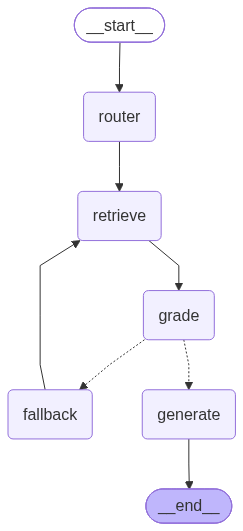

In [25]:
builder = StateGraph(AgentState)

builder.add_node("router", router_node)
builder.add_node("retrieve", retrieve_node)
builder.add_node("grade", grade_node)
builder.add_node("fallback", fallback_node)
builder.add_node("generate", generate_node)

builder.add_edge(START, "router")
builder.add_edge("router", "retrieve")
builder.add_edge("retrieve", "grade")
builder.add_conditional_edges("grade", route_after_grading, {
    "generate": "generate",
    "fallback": "fallback"
})
builder.add_edge("fallback", "retrieve")
builder.add_edge("generate", END)

agent = builder.compile()
print("Agentic Hybrid RAG Graph compiled successfully!")

# Display graph visualization
display(Image(agent.get_graph().draw_mermaid_png()))

This wires all five nodes together, matching the diagram shown earlier: `router` runs once at the start, `fallback` loops back to `retrieve` rather than to `router`, so the tool choice made at the very beginning (or swapped during a fallback) carries forward through every retry. `route_after_grading` still caps the loop at two fallback attempts, the same retry limit used in a simpler self-correcting agent.


### Step 13 — Run Test Queries


In [26]:
test_query = "What models or mechanisms are sequence transduction models based on or connected to?"

result = agent.invoke({
    "question": test_query,
    "current_tool": "",
    "retrieved_facts": [],
    "grade": "",
    "retry_count": 0,
    "final_answer": ""
})

print(f"Total Retries: {result['retry_count']}")

ROUTER DECISION: Using GRAPH Tool.
Retrieving for: 'What models or mechanisms are sequence transduction models based on or connected to?' via GRAPH Tool


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=2, column=13, offset=13>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 13, 'line': 2, 'column': 13}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n            CALL db.index.vector.queryNodes('concept_embeddings', 2, $vector)\n            YIELD node AS seed, score\n            MATCH (seed)-[r]-(neighbor:Concept)\n            RETURN seed.name + ' --[' + type(r) + ']-> ' + neighbor.name AS path\n            LIMIT 5\n            "


Grade: YES
Total Retries: 0


In [27]:
print(result["final_answer"])

--- FINAL ANSWER ---
Sequence transduction models are based on recurrent neural networks and convolutional neural networks, and they use encoder and decoder mechanisms.

--- EXPLAINABILITY ---
The answer is derived from the facts that sequence transduction models are BASED_ON recurrent neural networks and convolutional neural networks, and that they USE an encoder and a decoder. The fact that recurrent neural networks are also BASED_ON sequence transduction models indicates a bidirectional connection between the two.


The initial state starts with `current_tool` empty, since it hasn't been decided yet — the router node fills that in as the very first step of the run. Everything else starts empty or at zero, the same as a simpler self-correcting agent's starting state.


### Step 14 — Visualize the Retrieved Graph


In [28]:
from yfiles_jupyter_graphs import GraphWidget

with driver.session() as session:
    graph_result = session.run("MATCH (n)-[r]->(m) RETURN n, r, m")

widget = GraphWidget(graph=graph_result.graph())
display(widget)

GraphWidget(layout=Layout(height='800px', width='100%'))

This renders the full graph built in Step 5 as an interactive, zoomable widget inside the notebook — a way to see every node and relationship the agent had available to search through, regardless of which tool it ended up choosing for the test question.


# What We Learnt

By the end of this lab, a self-correcting agent has been given a choice between two different ways of searching the same knowledge graph, along with a fallback strategy that tries switching tools before it tries rewriting the question.

**Key takeaways:**
- **Routing lets one pipeline handle more than one kind of question well** — a router decision, made once per question, sends the search toward whichever tool suits it better.
- **A graph traversal and a vector search over the same data serve different needs** — one follows relationships outward, the other finds names close in meaning, and neither replaces the other.
- **A two-stage fallback tries the cheaper fix first** — swapping tools costs nothing in terms of rewording the question, so it's tried before anything more disruptive.
- **The tool choice carries through the whole loop** — once picked (or swapped), the same tool is reused on every retry, unless a fallback specifically decides to swap it again.
- **The retry limit still applies the same way** — regardless of whether a fallback swapped the tool or rewrote the question, the loop still stops after a fixed number of attempts and answers with whatever it has.
- **The same explainability format carries over** — every final answer still comes with a short trace of which facts or paths were actually used to build it.
